[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link]
<a href="javascript:void(0);" onclick="openJupyterWidget('https://github.com/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-PACE/level2.ipynb');">
    <img src="https://img.shields.io/badge/Open_in_JupyterHub-orange?style=for-the-badge" alt="JupyterHub Badge">
</a> [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link]

[download-link]: https://nmfs-opensci.github.io/NMFSHackDays-2025/topics-2025/2025-PACE/level2.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-PACE/level2.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/nmfshackdays-2025/main/topics-2025/2025-PACE/level2.ipynb

## Overview

The figures were generated from Level 2 products.

The PACE Level-2 OCI (ocean color instrument) data is available on an NASA EarthData. Search using the instrument filter "OCI" and processing level 2 filter <https://search.earthdata.nasa.gov/search?fi=OCI&fl=2%2B-%2BGeophys.%2BVariables%252C%2BSensor%2BCoordinates> and you will see 16 data collections. 

The Level 2 netcdf files are grouped with the geophysical data, lat/lon, and wavelength data in different groups. 

## Data collection used

#### PACE OCI Level-2 Regional Apparent Optical Properties Data, version 3.0
* https://cmr.earthdata.nasa.gov/search/concepts/C3385049983-OB_CLOUD.html
* remote sensing reflectance and avw
* short name: PACE_OCI_L2_AOP
* date: 2024-05-13
* spatial bin: T171853
* spatial extent: lat=[38.0,42.5]; lon=[-75.5,-69.0];
* filename: PACE_OCI.20240513T171853.L2.OC_AOP.V3_0_0.nc
      

### Prerequisites

You need to have an EarthData Login username and password. Go here to get one <https://urs.earthdata.nasa.gov/>

I assume you have a `.netrc` file at `~` (home). `~/.netrc` should look just like this with your username and password. Create that file if needed. You don't need to create it if you don't have this file. The `earthaccess.login(persist=True)` line will ask for your username and password and create the `.netrc` file for you.

```
machine urs.earthdata.nasa.gov
        login yourusername
        password yourpassword
```

#### For those not working in the JupyterHub

Uncomment this and run the cell:

In [1]:
# pip install earthaccess

## Rrs figures

### Get data

In [1]:
%%time
# Authenticate to NASA
import earthaccess
auth = earthaccess.login(strategy="interactive", persist=True)
    
# (xmin=-73.5, ymin=33.5, xmax=-43.5, ymax=43.5)
bbox = (-75.5, 38.0, -69.0, 42.5)
import earthaccess
results = earthaccess.search_data(
    short_name = "PACE_OCI_L2_AOP",
    temporal = ("2024-05-13", "2024-05-13"),
    bounding_box = bbox
)
fileset = earthaccess.open(results);

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 475 ms, sys: 77 ms, total: 552 ms
Wall time: 8 s


### Examine the groups

In [3]:
import h5netcdf
with h5netcdf.File(fileset[0]) as file:
    groups = list(file)
groups

['sensor_band_parameters',
 'scan_line_attributes',
 'geophysical_data',
 'navigation_data',
 'processing_control']

### Process data and subset

In [4]:
%%time
import xarray as xr
ds = xr.open_dataset(fileset[0], group="geophysical_data")

# Add coords
# Add coords
nav = xr.open_dataset(fileset[0], group="navigation_data")
nav = nav.set_coords(("longitude", "latitude"))
wave = xr.open_dataset(fileset[0], group="sensor_band_parameters")
wave = wave.set_coords(("wavelength_3d"))
dataset = xr.merge((ds["Rrs"], nav.coords, wave.coords))

# Subset
rrs_box = dataset.where(
    (
        (dataset["latitude"] > 38.0)
        & (dataset["latitude"] < 42.5)
        & (dataset["longitude"] > -75.5)
        & (dataset["longitude"] < -69.0)
    ),
    drop = True
)

CPU times: user 12.6 s, sys: 6.03 s, total: 18.6 s
Wall time: 54.7 s


### Make plots

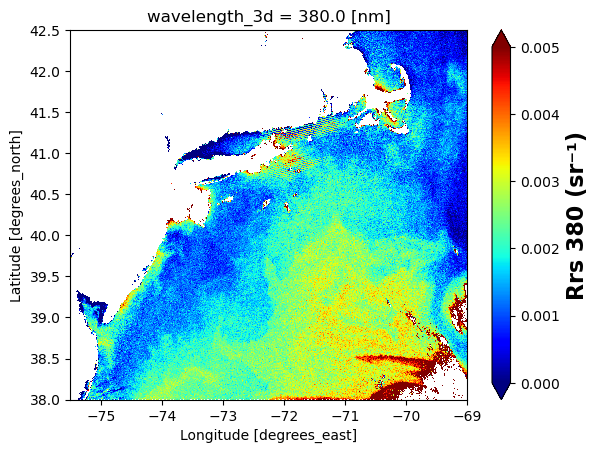

In [10]:
# make single plot
import matplotlib.pyplot as plt

rrs = rrs_box["Rrs"].sel(wavelength_3d = 380)
plot = rrs.plot(x="longitude", y="latitude", cmap="jet", vmin=0, vmax=0.005)

# Set x and y limits
plot.axes.set_xlim(-75.5, -69.0)
plot.axes.set_ylim(38.0, 42.5)

# Customize colorbar label
wave_string = "380"  # or str(wavelength) if dynamic
plot.colorbar.set_label(f"Rrs {wave_string} (sr⁻¹)", fontsize=16, fontweight="bold")

plt.show()

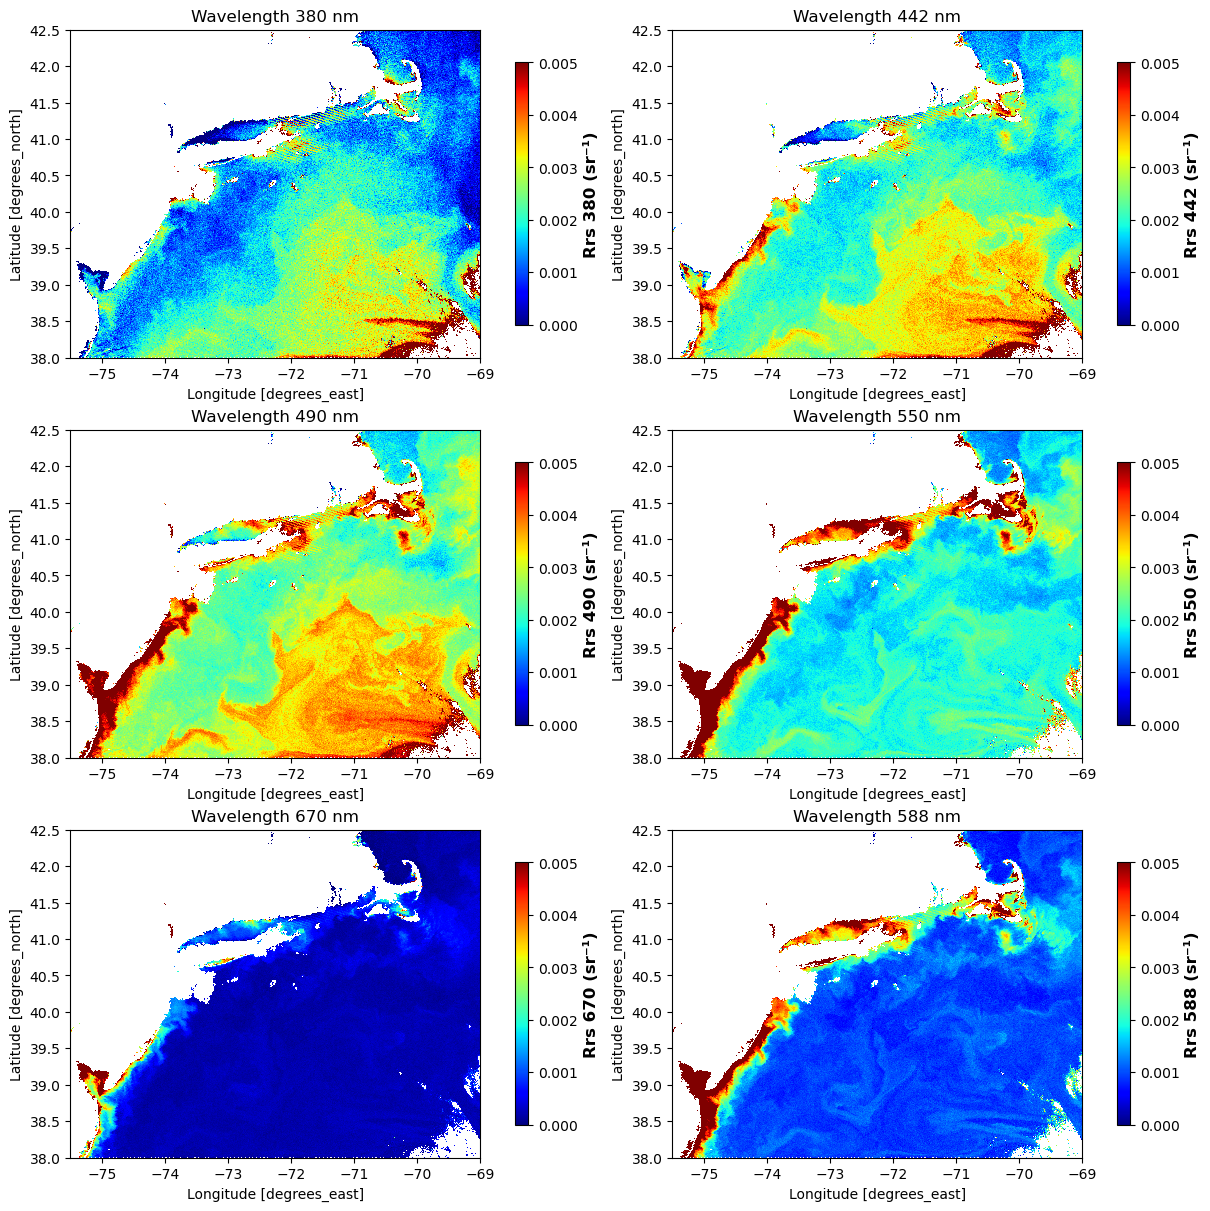

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# List of wavelengths to plot
wavelengths = [380, 442, 490, 550, 670, 588]

# Create figure and axes
fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)
axes = axes.flatten()

# Loop through wavelengths and plot
for i, wl in enumerate(wavelengths):
    ax = axes[i]
    
    # Extract Rrs and mask zeros (for log or safety)
    rrs = rrs_box["Rrs"].sel(wavelength_3d=wl)
    
    # Plot onto the provided axis
    img = rrs.plot(
        ax=ax,
        x="longitude",
        y="latitude",
        cmap="jet",
        vmin=0,
        vmax=0.005,
        add_colorbar=False  # We'll add our own
    )
    
    # Set limits
    ax.set_xlim(-75.5, -69.0)
    ax.set_ylim(38.0, 42.5)
    
    # Add colorbar
    cbar = fig.colorbar(img, ax=ax, orientation="vertical", shrink=0.8)
    cbar.set_label(f"Rrs {wl} (sr⁻¹)", fontsize=12, fontweight="bold")
    
    # Optional: title or annotation
    ax.set_title(f"Wavelength {wl} nm")

# Turn off unused axes (if any)
for j in range(len(wavelengths), len(axes)):
    fig.delaxes(axes[j])

plt.show()


## AVW figures

### Get and set up data

In [12]:
%%time
# Authenticate to NASA
import earthaccess
auth = earthaccess.login(strategy="interactive", persist=True)
    
# (xmin=-73.5, ymin=33.5, xmax=-43.5, ymax=43.5)
bbox = (-75.5, 38.0, -69.0, 42.5)
import earthaccess
results = earthaccess.search_data(
    short_name = "PACE_OCI_L2_AOP",
    temporal = ("2024-05-13", "2024-05-13"),
    bounding_box = bbox
)
fileset = earthaccess.open(results);

# load data
import xarray as xr
ds = xr.open_dataset(fileset[0], group="geophysical_data")

# Add coords
# Add coords
nav = xr.open_dataset(fileset[0], group="navigation_data")
nav = nav.set_coords(("longitude", "latitude"))
wave = xr.open_dataset(fileset[0], group="sensor_band_parameters")
wave = wave.set_coords(("wavelength_3d"))
dataset = xr.merge((ds["avw"], nav.coords, wave.coords))

# Subset
avw_box = dataset.where(
    (
        (dataset["latitude"] > 38.0)
        & (dataset["latitude"] < 42.5)
        & (dataset["longitude"] > -75.5)
        & (dataset["longitude"] < -69.0)
    ),
    drop = True
)

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 5.44 s, sys: 3.05 s, total: 8.49 s
Wall time: 36.9 s


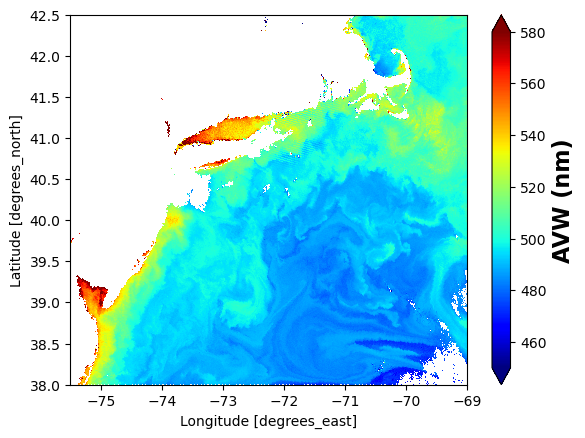

In [14]:
# make one plot
import matplotlib.pyplot as plt

plot = avw_box["avw"].plot(x="longitude", y="latitude", cmap="jet", vmin=450, vmax=580)

# Set x and y limits
plot.axes.set_xlim(-75.5, -69.0)
plot.axes.set_ylim(38.0, 42.5)

# Customize colorbar label
plot.colorbar.set_label("AVW (nm)", fontsize=16, fontweight="bold")

plt.show()

## References

* [An Introduction to Earth and Environmental Data Science](https://earth-env-data-science.github.io)
* [xarray user guide](https://docs.xarray.dev/en/stable/user-guide/index.html)